# Pipeline de Validación paso a paso - ResUnet (Clasificación de Tejidos)

Este notebook permite validar de forma interactiva y paso a paso el pipeline de datos, preprocesamiento, arquitectura del modelo, y un paso de entrenamiento de prueba para la red neural.

### 1. Configurar Entorno y Añadir Rutas al Sistema

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Encontrar la raíz del repositorio
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
print(f"Raíz del Repositorio: {REPO_ROOT}")

# Definir la ruta del modelo y añadirla al path para importar módulos locales
MODEL_DIR = os.path.join(REPO_ROOT, "src", "ClasificationAlgorithms", "Models", "ResUnet")
sys.path.append(MODEL_DIR)
print(f"Ruta del Modelo: {MODEL_DIR}")

/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raíz del Repositorio: /home/diego-villalba/Proyecto_DFU
Ruta del Modelo: /home/diego-villalba/Proyecto_DFU/src/ClasificationAlgorithms/Models/ResUnet


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### 2. Importar Componentes Locales
Importamos el dataset, las transformaciones, y la arquitectura de la red neural.

In [2]:
from utils import get_loaders
from main import ResUnet
model_name = "ResUnet"
print("Módulos locales importados correctamente.")

Probando el modelo...


El modelo funciona correctamente.
(Time of 2 224x224 imgs:  0.31 s)


Módulos locales importados correctamente.


### 3. Cargar y Visualizar Muestras del Dataset
Cargamos las imágenes y máscaras correspondientes desde la carpeta central de datos y visualizamos una muestra.

Tamaño del Batch de Imágenes: torch.Size([2, 3, 240, 240])
Tamaño del Batch de Máscaras: torch.Size([2, 240, 240])


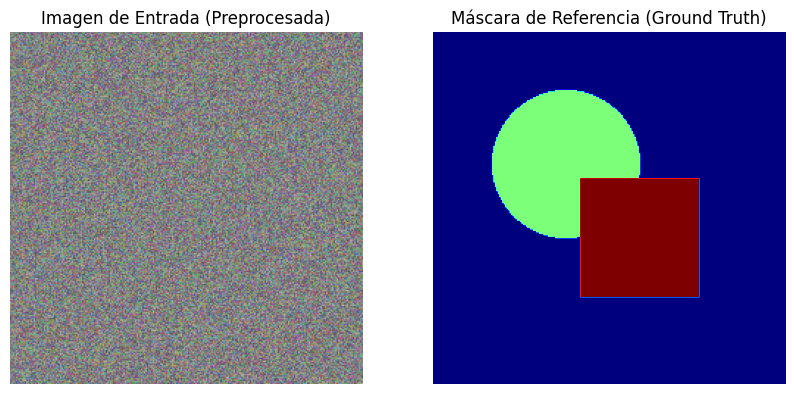

In [3]:
TRAIN_IMG_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "train_images")
TRAIN_MASK_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "train_masks")
VAL_IMG_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "val_images")
VAL_MASK_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "val_masks")

train_transform = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2()
])

train_loader, val_loader = get_loaders(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR,
    batch_size=2, train_transform=train_transform, val_transform=train_transform,
    num_workers=0, pin_memory=True
)

# Extraer una muestra
images, masks = next(iter(train_loader))
print(f"Tamaño del Batch de Imágenes: {images.shape}")
print(f"Tamaño del Batch de Máscaras: {masks.shape}")

# Visualizar imagen y máscara
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(images[0].permute(1, 2, 0).numpy())
ax[0].set_title("Imagen de Entrada (Preprocesada)")
ax[0].axis("off")
ax[1].imshow(masks[0].numpy(), cmap="gray" if masks[0].max() <= 1 else "jet")
ax[1].set_title("Máscara de Referencia (Ground Truth)")
ax[1].axis("off")
plt.show()

### 4. Inicializar y Validar el Modelo
Cargamos la red y pasamos un batch para confirmar que las dimensiones de entrada y salida coincidan.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_class = ResUnet
model = model_class(in_channels=3, out_channels=4).to(DEVICE)
print(f"Modelo {model_name} cargado en {DEVICE}.")

# Forward pass de prueba
with torch.no_grad():
    dummy_input = images.to(DEVICE)
    dummy_output = model(dummy_input)
    print(f"Dimensión de Entrada: {dummy_input.shape}")
    print(f"Dimensión de Salida de la Red: {dummy_output.shape}")

Modelo ResUnet cargado en cuda.


Dimensión de Entrada: torch.Size([2, 3, 240, 240])
Dimensión de Salida de la Red: torch.Size([2, 4, 240, 240])


### 5. Paso de Entrenamiento de Prueba (One Step Training)
Ejecutamos un paso de optimización (forward pass, pérdida, backward pass y actualización de gradientes) para comprobar el pipeline completo.

In [5]:
import torch.nn as nn
import torch.optim as optim
from metrics import dice_loss_multiclass

loss_fn = dice_loss_multiclass
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = torch.amp.GradScaler('cuda') if DEVICE == "cuda" else None

# Simular paso de entrenamiento
model.train()
data = images.to(DEVICE)
targets = masks.float().unsqueeze(1).to(DEVICE)

optimizer.zero_grad()
if scaler:
    with torch.amp.autocast('cuda'):
        predictions = model(data)
        loss = loss_fn(predictions, targets)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
else:
    predictions = model(data)
    loss = loss_fn(predictions, targets)
    loss.backward()
    optimizer.step()

print(f"Paso de prueba completado con éxito.")
print(f"Pérdida obtenida en el paso: {loss.item():.4f}")

Paso de prueba completado con éxito.
Pérdida obtenida en el paso: 0.8394
